In [34]:
import pandas as pd
import numpy as np
import os
import glob
import shutil
import scipy.stats as stats
import scipy.signal as signal
from scipy.ndimage import gaussian_filter1d
import sys

In [35]:
# Recursively find all CSV files in the Simulated_Waveforms directory
search_path = os.path.join('Simulated_Waveforms', '*.csv')
channel_files = glob.glob(search_path)

results = [] # This list will be passed by reference to accumulate results

if not channel_files:
    print(f"No channel files found in {search_path}")
    sys.exit()

# Read all channels into a dictionary of dataframes, to be used later
# At the same time, process each channel and isolate the waveforms
print(f"Loading {len(channel_files)} channel files into memory...")
channel_dataframes = {}
for filepath in channel_files:
    filename = os.path.basename(filepath)
    try:
        # Load the CSV file without headers
        df = pd.read_csv(filepath, header=None)
        channel_dataframes[filename] = df
    except Exception as e:
        print(f"  Error loading {filename}: {e}")
        
if not channel_dataframes:
    print("No dataframes loaded. Exiting.")
    sys.exit()

indices_df = pd.read_csv('Waveform_Analysis.csv')

Loading 4 channel files into memory...


In [36]:
import Envelope_Analysis as EA

EA.cluster_waveforms_2(channel_dataframes)

In [37]:
import Wavelet_Decomposition as WD
# 2. Pre-load channel files into memory


# 3. Process each isolated waveform
print(f"Extracting features for {len(indices_df)} waveforms...")

results = []

for i, row in indices_df.iterrows():
    filename = row['input filename']
    start_idx = int(row['start idx'])
    end_idx = int(row['end idx'])
    count = row['count']
    
    # Extract signal from the pre-loaded dataframes
    try:
        df = channel_dataframes[filename]
        signal_segment = df.iloc[start_idx:end_idx, 1].values
        
        # Extract features
        energies = WD.calculate_wavelet_energy(signal_segment)
        
        if energies is not None:
            res_row = {
                'input filename': filename,
                'count': count,
                'Energy_A5': energies[0],
                'Energy_D5': energies[1],
                'Energy_D4': energies[2],
                'Energy_D3': energies[3],
                'Energy_D2': energies[4],
                'Energy_D1': energies[5]
            }
            results.append(res_row)
            
    except Exception as e:
        print(f"Error processing {filename} #{count}: {e}")

# 4. Save results to CSV
if results:
    new_df = pd.DataFrame(results)
        
    if os.path.exists(WD.OUTPUT_FILE):
        existing_df = pd.read_csv(WD.OUTPUT_FILE)
        # Merge new results as columns. 
        # We assume 'Filename' is the common identifier for rows.
        if 'input filename' in existing_df.columns and 'count' in existing_df.columns:
            # Merge on Filename and Count to ensure rows match correctly
            # 'outer' join ensures we don't lose rows
            final_df = pd.merge(existing_df, new_df, on=['input filename', 'count'], how='outer')
        else:
            # Fallback: if keys are missing, just concatenate columns
            final_df = pd.concat([existing_df, new_df], axis=1)
        
        final_df.to_csv(WD.OUTPUT_FILE, index=False)
        print(f"Processing complete. Data appended as columns to {WD.OUTPUT_FILE}")
    else:
        new_df.to_csv(WD.OUTPUT_FILE, index=False)
        print(f"Processing complete. Data saved to {WD.OUTPUT_FILE}")
else:
    print("No features extracted.")

Extracting features for 24 waveforms...
Processing complete. Data appended as columns to Waveform_Analysis.csv


Loading data from Waveform_Analysis.csv...
Computing Principal Components...
Explained Variance by component: [0.8907429  0.10242509 0.00640958]
Total Information Retained: 99.96%
PCA results appended to Waveform_Analysis.csv
Generating 3D Plot...


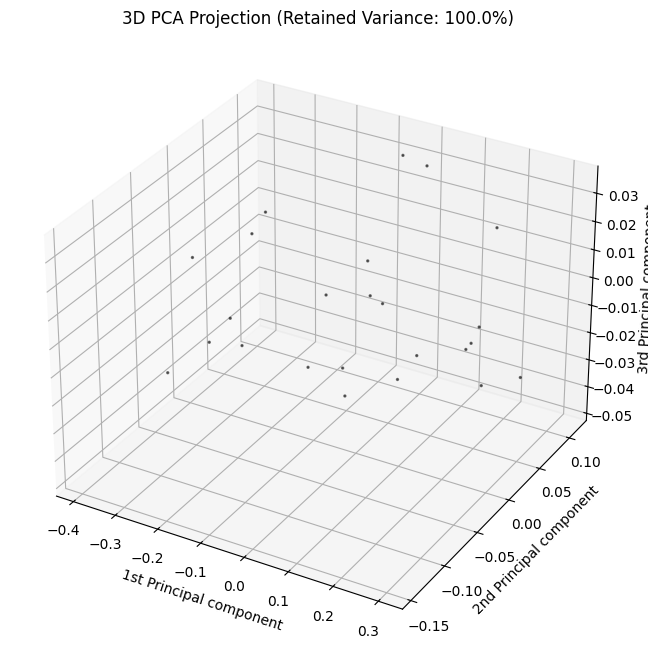

In [38]:
import Principal_Component_Analysis as pca

pca.perform_pca_and_visualize('Waveform_Analysis.csv')

In [39]:
import DBSCAN as dbscan

dbscan.perform_simple_clustering('Waveform_Analysis.csv')

Loading data from Waveform_Analysis.csv...
Simple PCA clustering complete. Data saved back to Waveform_Analysis.csv


d:\Zee_Documents\Studies\Uni\Sem_7\KIE4002_FYP\Python\Measured Data CSV Analysis\DBSCAN.py:130: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ch1_df['Simple PCA Feature Cluster ID'] = ch1_df['count']
d:\Zee_Documents\Studies\Uni\Sem_7\KIE4002_FYP\Python\Measured Data CSV Analysis\DBSCAN.py:131: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ch2_df['Simple PCA Feature Cluster ID'] = 0
d:\Zee_Documents\Studies\Uni\Sem_7\KIE4002_FYP\Python\Measured Data CSV Analysis\DBSCAN.py:132: SettingWithCopyWarning: 
A val

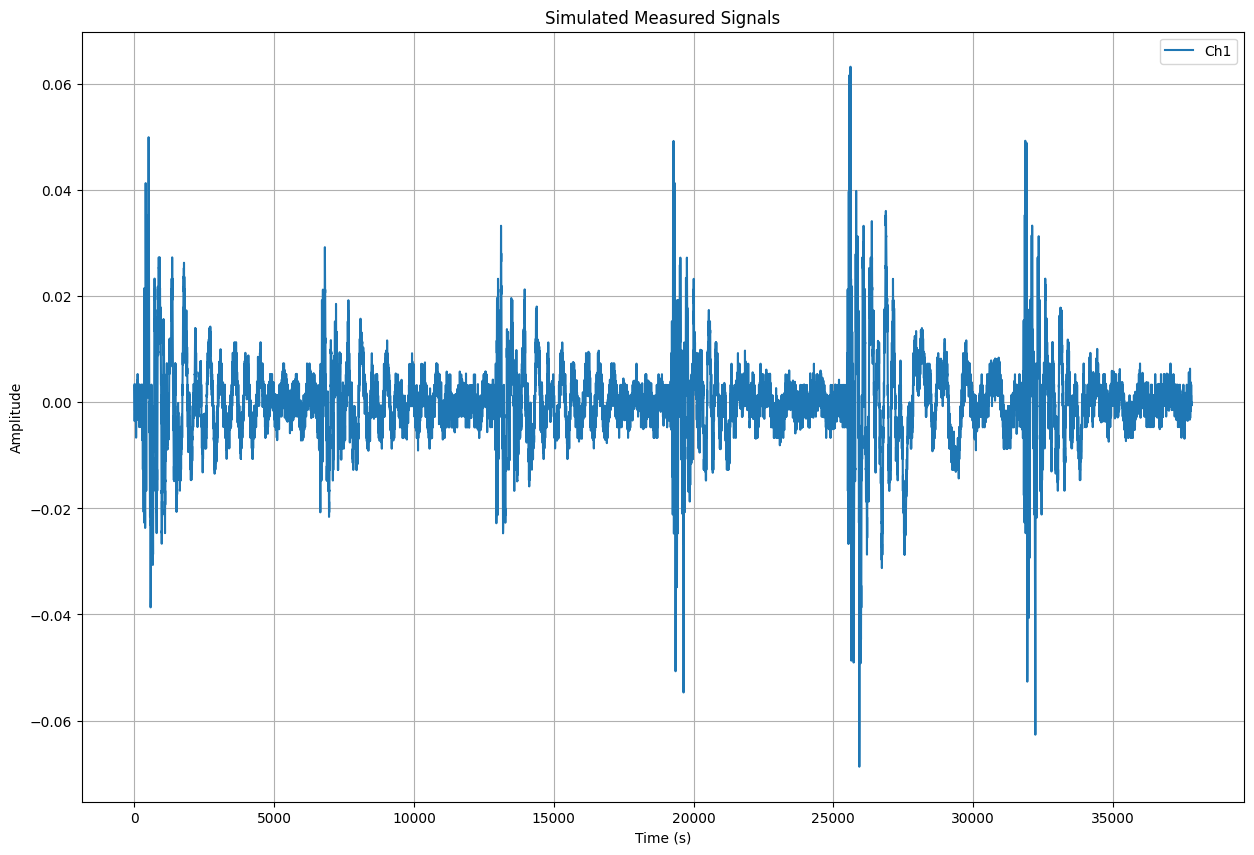

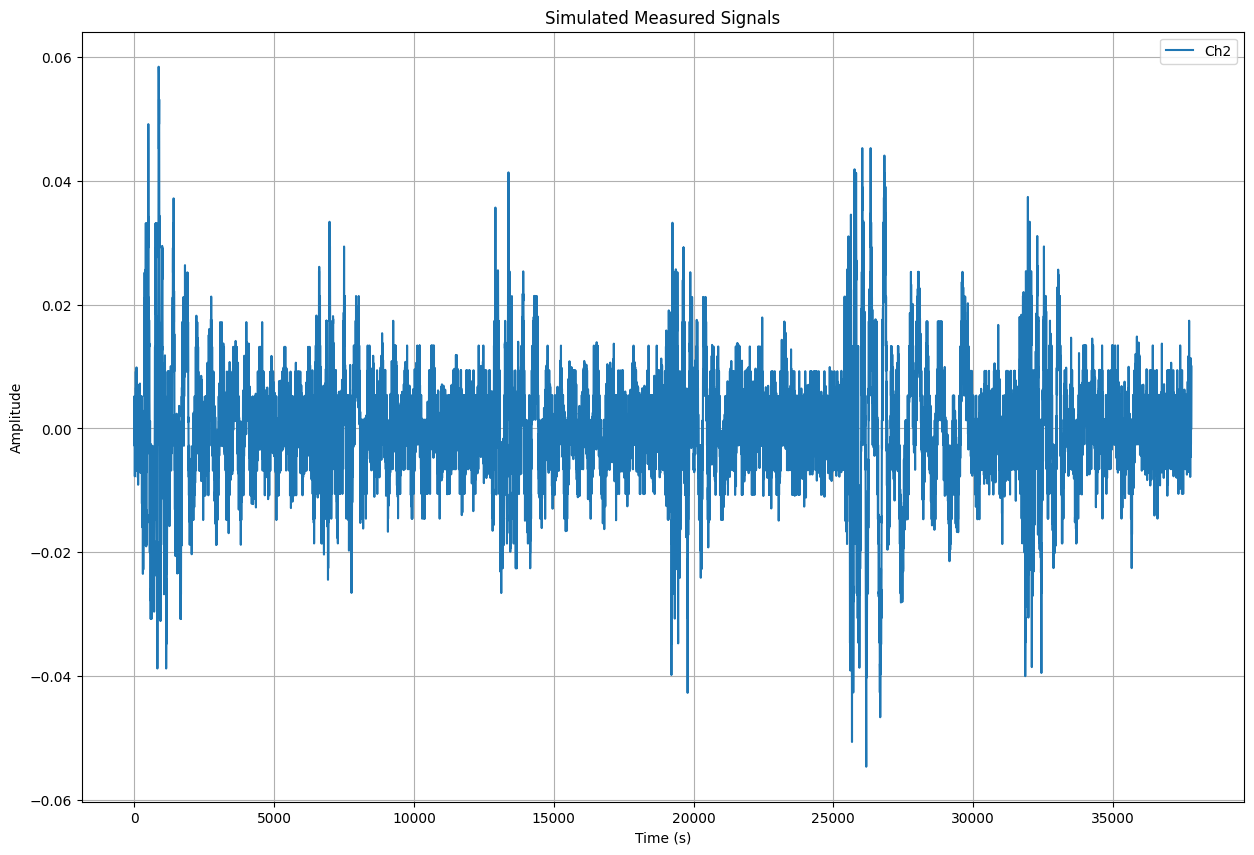

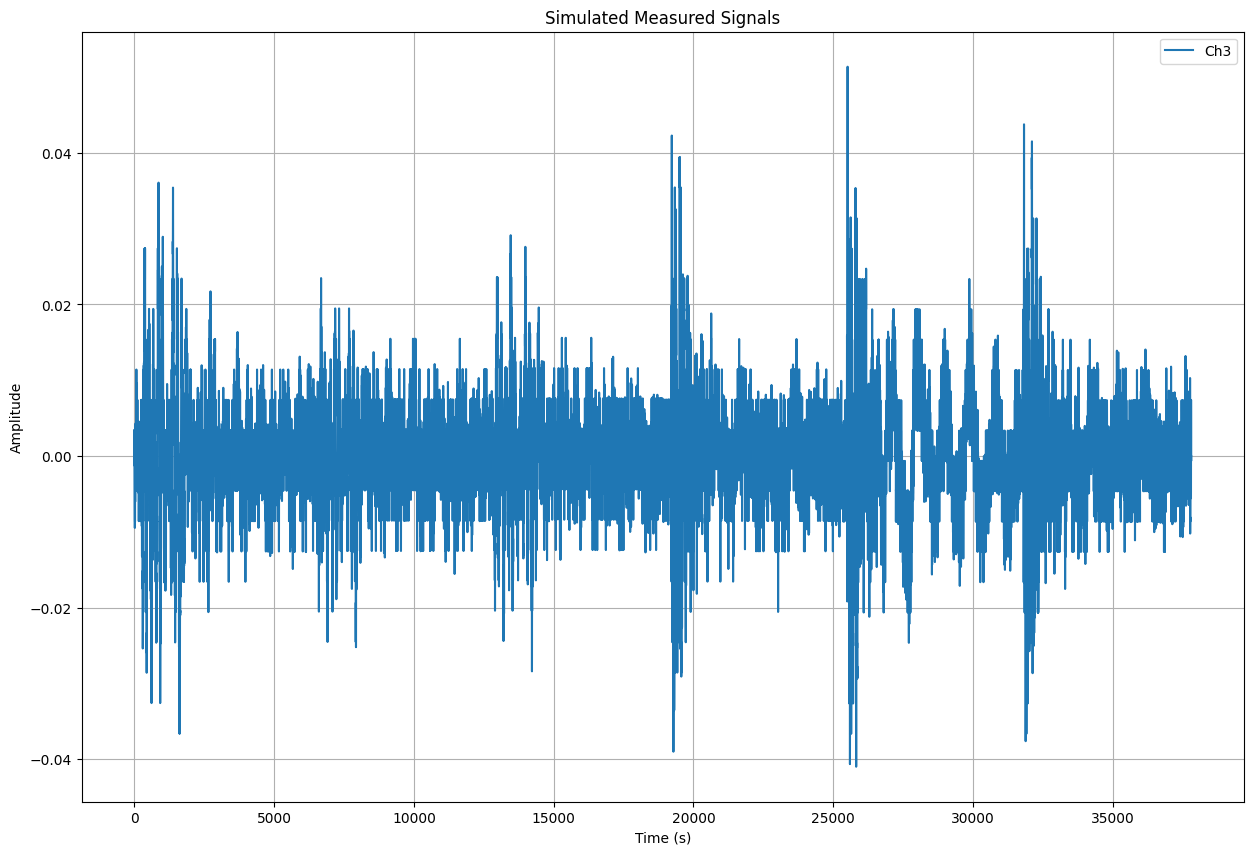

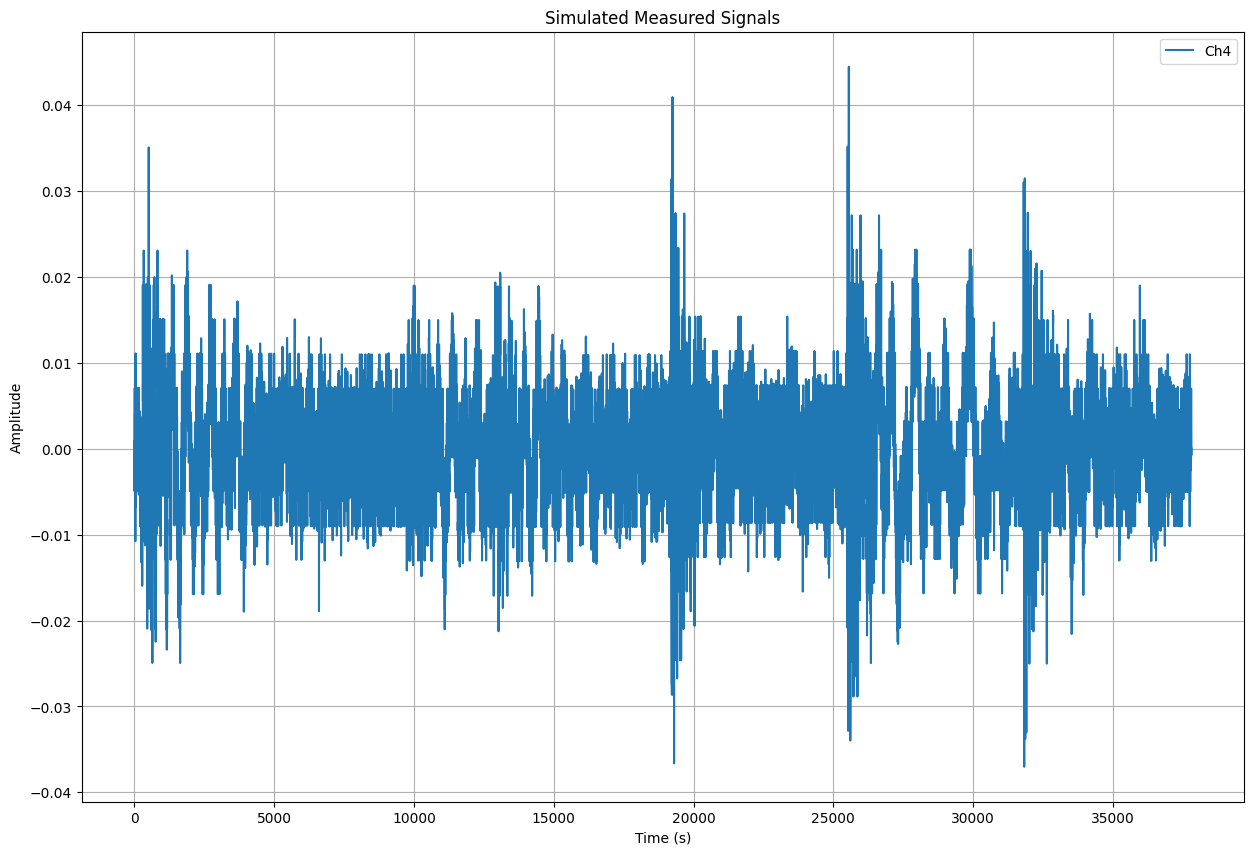

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Directory containing the files
data_dir = 'Simulated_Waveforms'
files = ['Ch1.csv', 'Ch2.csv', 'Ch3.csv', 'Ch4.csv']


for filename in files:
    plt.figure(figsize=(15, 10))
    filepath = os.path.join(data_dir, filename)
    
    if os.path.exists(filepath):
        # Read the CSV file. Assuming no header based on file inspection.
        # Column 0 is Time, Column 1 is Signal Amplitude
        df = pd.read_csv(filepath, header=None)
        
        plt.plot(df[1], label=filename.replace('.csv', ''))
    
        plt.title("Simulated Measured Signals")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.grid(True)
        plt.show()
    else:
        print(f"Warning: {filename} not found in {data_dir}")

C:\Users\chian\AppData\Local\Temp\ipykernel_10956\2571914413.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


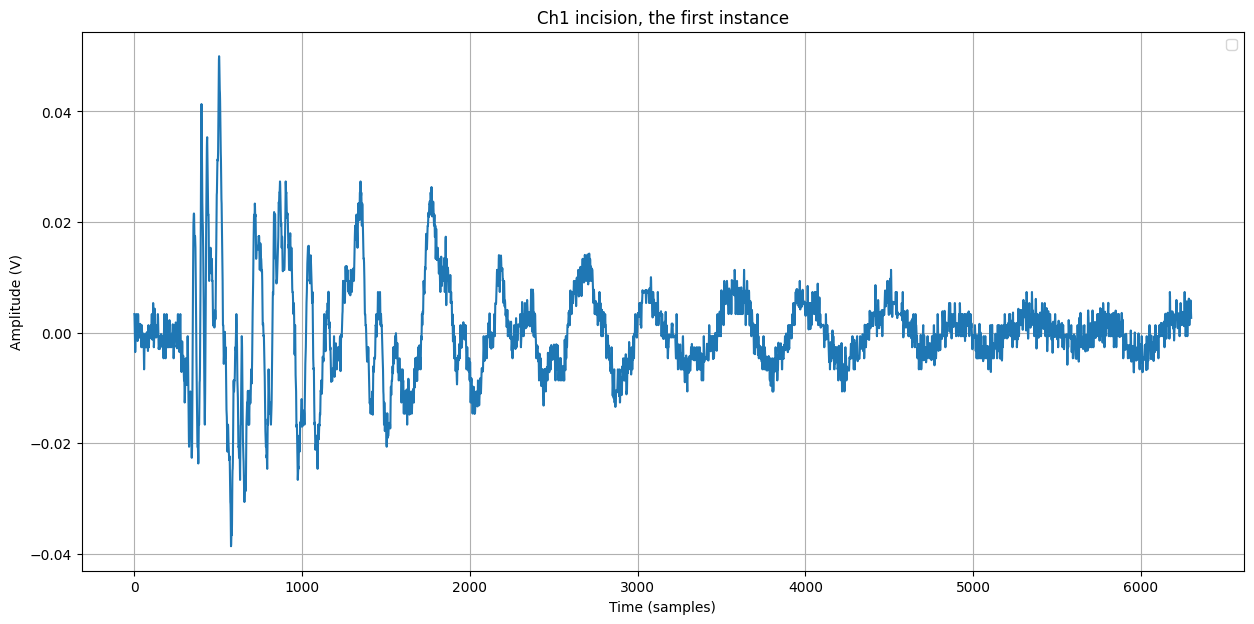

C:\Users\chian\AppData\Local\Temp\ipykernel_10956\2571914413.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


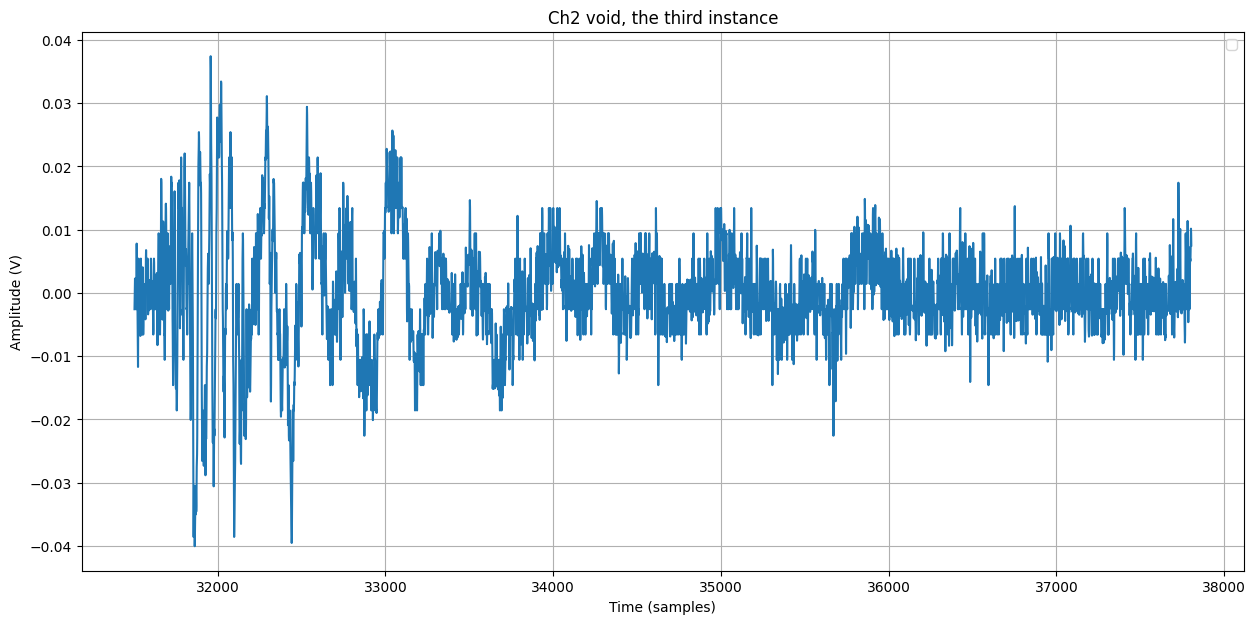

C:\Users\chian\AppData\Local\Temp\ipykernel_10956\2571914413.py:39: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


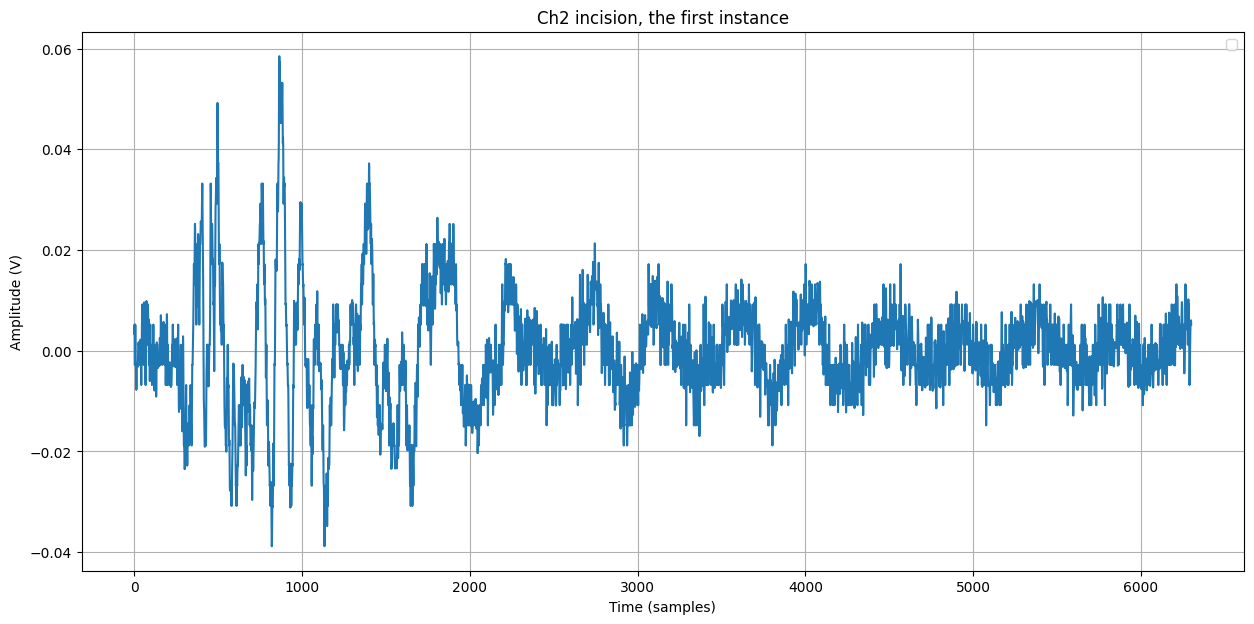

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

data_dir = 'Simulated_Waveforms'


filepath = os.path.join(data_dir, 'Ch1.csv')
    
df = pd.read_csv(filepath, header=None)

plt.figure(figsize=(15, 7))
plt.plot(df[1][0:6300])
plt.title("Ch1 incision, the first instance")
plt.ylabel("Amplitude (V)")
plt.xlabel("Time (samples)")
plt.legend()
plt.grid(True)
plt.show()

filepath = os.path.join(data_dir, 'Ch2.csv')
    
df = pd.read_csv(filepath, header=None)

plt.figure(figsize=(15, 7))
plt.plot(df[1][31505:37805])
plt.title("Ch2 void, the third instance")
plt.ylabel("Amplitude (V)")
plt.xlabel("Time (samples)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 7))
plt.plot(df[1][0:6300])
plt.title("Ch2 incision, the first instance")
plt.ylabel("Amplitude (V)")
plt.xlabel("Time (samples)")
plt.legend()
plt.grid(True)
plt.show()

filepath = os.path.join(data_dir, 'Ch3.csv')
    
df = pd.read_csv(filepath, header=None)


